# 04 - Neural Network Models for Gasoline Price Forecasting

This notebook implements neural network approaches using **PyTorch** on Google Colab:

1. **MLP (Multi-Layer Perceptron)** with three architectures (Small, Medium, Large)
2. **LSTM (Long Short-Term Memory)** with four configurations
3. **GRU (Gated Recurrent Unit)** as a bonus comparison model

**Horizons:** 1-week and 4-week ahead forecasting

---

**Instructions:** Upload `PET_PRI_GND_DCUS_NUS_W.csv` when prompted in the next cell.

In [1]:
# Upload the CSV data file
from google.colab import files
uploaded = files.upload()
print(f'Uploaded files: {list(uploaded.keys())}')

Saving PET_PRI_GND_DCUS_NUS_W.csv to PET_PRI_GND_DCUS_NUS_W.csv
Uploaded files: ['PET_PRI_GND_DCUS_NUS_W.csv']


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import warnings
import copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

PyTorch version: 2.10.0+cu128
Device: cuda


## 1. Utility Functions

Self-contained data loading, feature engineering, evaluation, and result-saving functions
(adapted from `src/data_utils.py` and `src/evaluate.py`).

In [3]:
# ---------------------------------------------------------------------------
# Data utilities (from src/data_utils.py)
# ---------------------------------------------------------------------------
TARGET_COL = 'A1'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)


def load_raw_data(filename='PET_PRI_GND_DCUS_NUS_W.csv'):
    """Load the raw CSV dataset from the uploaded file."""
    df = pd.read_csv(filename)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.sort_values('Date').reset_index(drop=True)
    return df


def clean_data(df):
    """Clean the dataset: handle missing values, ensure numeric types."""
    price_cols = [c for c in df.columns if c != 'Date']
    for col in price_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[price_cols] = df[price_cols].ffill().bfill()
    return df


def add_features(df, target_col=TARGET_COL, lags=None, rolling_windows=None):
    """Add time series features for modeling."""
    if lags is None:
        lags = [1, 2, 3, 4, 8, 12]
    if rolling_windows is None:
        rolling_windows = [4, 8, 12]

    df = df.copy()

    # Lag features of target
    for lag in lags:
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)

    # Rolling statistics
    for w in rolling_windows:
        df[f'{target_col}_rolling_mean_{w}'] = df[target_col].shift(1).rolling(w).mean()
        df[f'{target_col}_rolling_std_{w}'] = df[target_col].shift(1).rolling(w).std()

    # Price change features
    df[f'{target_col}_diff_1'] = df[target_col].diff(1)
    df[f'{target_col}_diff_4'] = df[target_col].diff(4)
    df[f'{target_col}_pct_change_1'] = df[target_col].pct_change(1)
    df[f'{target_col}_pct_change_4'] = df[target_col].pct_change(4)

    # Date features
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['year'] = df['Date'].dt.year
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

    # Cyclical month encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Other grade prices as features (lagged by 1 to avoid leakage)
    other_price_cols = [c for c in ['R1', 'M1', 'P1', 'D1'] if c != target_col]
    for col in other_price_cols:
        if col in df.columns:
            df[f'{col}_lag1'] = df[col].shift(1)

    return df


def create_target(df, target_col=TARGET_COL, horizon=1):
    """Create the prediction target: price at t+horizon."""
    df = df.copy()
    df['target'] = df[target_col].shift(-horizon)
    return df


def get_feature_columns(df, mode='full'):
    """Get feature column names based on mode."""
    exclude = {'Date', 'target', TARGET_COL,
               'A1', 'A2', 'A3', 'R1', 'R2', 'R3',
               'M1', 'M2', 'M3', 'P1', 'P2', 'P3', 'D1'}
    if mode == 'basic':
        return [c for c in df.columns if c.startswith(f'{TARGET_COL}_lag')]
    else:
        return [c for c in df.columns if c not in exclude]


def train_val_test_split(df, train_ratio=0.70, val_ratio=0.15):
    """Chronological train/val/test split."""
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()


def prepare_data(horizon=1, feature_mode='full'):
    """End-to-end data preparation pipeline."""
    df = load_raw_data()
    df = clean_data(df)
    df = add_features(df)
    df = create_target(df, horizon=horizon)
    df = df.dropna().reset_index(drop=True)
    feature_cols = get_feature_columns(df, mode=feature_mode)
    train_df, val_df, test_df = train_val_test_split(df)
    return {
        'train': train_df, 'val': val_df, 'test': test_df,
        'feature_cols': feature_cols, 'full_df': df,
    }


# ---------------------------------------------------------------------------
# Evaluation utilities (from src/evaluate.py)
# ---------------------------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(y_true, y_pred):
    """Compute all metrics and return as dict."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return {
        'RMSE': round(float(rmse(y_true, y_pred)), 6),
        'MAE': round(float(mae(y_true, y_pred)), 6),
        'MAPE': round(float(mape(y_true, y_pred)), 4),
    }


def save_results(model_name, horizon, metrics, predictions=None,
                 dates=None, feature_mode='full'):
    """Save model results to JSON file."""
    os.makedirs(RESULTS_DIR, exist_ok=True)
    safe_name = model_name.replace(' ', '_').replace('/', '_').lower()
    filename = f'{safe_name}_h{horizon}_{feature_mode}.json'
    result = {
        'model_name': model_name,
        'horizon': horizon,
        'feature_mode': feature_mode,
        'metrics': metrics,
    }
    if predictions is not None:
        result['predictions'] = {
            k: v.tolist() if hasattr(v, 'tolist') else list(v)
            for k, v in predictions.items()
        }
    if dates is not None:
        result['dates'] = {
            k: [str(d) for d in v] for k, v in dates.items()
        }
    filepath = os.path.join(RESULTS_DIR, filename)
    with open(filepath, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'Results saved to {filepath}')


def plot_predictions_vs_actual(dates, y_true, y_pred, model_name, title=None):
    """Plot predicted vs actual prices."""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates, y_true, label='Actual', color='black', linewidth=1.5)
    ax.plot(dates, y_pred, label=f'{model_name}', color='tab:blue',
            linewidth=1.2, alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($/gallon)')
    ax.set_title(title or f'{model_name}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


print('Utility functions defined.')

Utility functions defined.


## 2. Load and Prepare Data

In [4]:
# Load data for horizon=1
data = prepare_data(horizon=1, feature_mode='full')

train_df = data['train']
val_df = data['val']
test_df = data['test']
feature_cols = data['feature_cols']

print(f'Number of features: {len(feature_cols)}')
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Feature columns: {feature_cols}')

Number of features: 26
Train: 943, Val: 202, Test: 203
Feature columns: ['A1_lag1', 'A1_lag2', 'A1_lag3', 'A1_lag4', 'A1_lag8', 'A1_lag12', 'A1_rolling_mean_4', 'A1_rolling_std_4', 'A1_rolling_mean_8', 'A1_rolling_std_8', 'A1_rolling_mean_12', 'A1_rolling_std_12', 'A1_diff_1', 'A1_diff_4', 'A1_pct_change_1', 'A1_pct_change_4', 'month', 'quarter', 'year', 'week_of_year', 'month_sin', 'month_cos', 'R1_lag1', 'M1_lag1', 'P1_lag1', 'D1_lag1']


In [5]:
# Extract arrays and standardize
X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_val = val_df[feature_cols].values
y_val = val_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]')

X_train shape: (943, 26)
y_train range: [0.95, 4.17]


## 3. MLP Model (PyTorch)

A multi-layer perceptron with configurable hidden layers, BatchNorm, ReLU activations, and Dropout.

In [6]:
class MLP(nn.Module):
    """Multi-Layer Perceptron with BatchNorm and Dropout."""

    def __init__(self, input_size, hidden_sizes, dropout=0.2):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


def train_mlp(model, train_loader, val_loader, epochs=200, patience=20, lr=1e-3):
    """
    Train an MLP model with Adam, MSELoss, ReduceLROnPlateau, and early stopping.
    Returns the best model (by val loss), train losses, and val losses.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        # Validation
        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
                n_val += 1
        val_loss /= n_val
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch + 1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}: train_loss={train_losses[-1]:.6f}, '
                  f'val_loss={val_loss:.6f}, lr={optimizer.param_groups[0]["lr"]:.6f}')

    # Restore best model
    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_mlp(model, X_np):
    """Get predictions from MLP as a numpy array."""
    model.eval()
    X_t = torch.FloatTensor(X_np).to(device)
    with torch.no_grad():
        preds = model(X_t).cpu().numpy()
    return preds


print('MLP class and training functions defined.')

MLP class and training functions defined.


### 3.1 Experiment with MLP Architectures

We test three architectures:
- **MLP-Small:** [64, 32]
- **MLP-Medium:** [128, 64, 32]
- **MLP-Large:** [256, 128, 64, 32]

In [7]:
# Create DataLoaders
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# MLP configurations
mlp_configs = {
    'MLP-Small':  [64, 32],
    'MLP-Medium': [128, 64, 32],
    'MLP-Large':  [256, 128, 64, 32],
}

mlp_results = {}
input_size = X_train_scaled.shape[1]

for name, hidden_sizes in mlp_configs.items():
    print(f'\n{"="*60}')
    print(f'Training {name}: hidden_sizes={hidden_sizes}')
    print(f'{"="*60}')

    torch.manual_seed(SEED)
    model = MLP(input_size, hidden_sizes, dropout=0.2)
    print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

    model, t_losses, v_losses = train_mlp(
        model, train_loader, val_loader,
        epochs=200, patience=20, lr=1e-3
    )

    val_pred = predict_mlp(model, X_val_scaled)
    test_pred = predict_mlp(model, X_test_scaled)

    val_metrics = evaluate_model(y_val, val_pred)
    test_metrics = evaluate_model(y_test, test_pred)

    mlp_results[name] = {
        'model': model,
        'train_losses': t_losses,
        'val_losses': v_losses,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'val_pred': val_pred,
        'test_pred': test_pred,
    }

    print(f'  Epochs trained: {len(t_losses)}')
    print(f'  Val  - RMSE: {val_metrics["RMSE"]:.4f}, MAE: {val_metrics["MAE"]:.4f}, MAPE: {val_metrics["MAPE"]:.2f}%')
    print(f'  Test - RMSE: {test_metrics["RMSE"]:.4f}, MAE: {test_metrics["MAE"]:.4f}, MAPE: {test_metrics["MAPE"]:.2f}%')


Training MLP-Small: hidden_sizes=[64, 32]
  Parameters: 4,033
  Early stopping at epoch 39
  Epochs trained: 39
  Val  - RMSE: 0.1343, MAE: 0.1117, MAPE: 4.00%
  Test - RMSE: 0.1593, MAE: 0.1317, MAPE: 5.23%

Training MLP-Medium: hidden_sizes=[128, 64, 32]
  Parameters: 14,273
  Early stopping at epoch 30
  Epochs trained: 30
  Val  - RMSE: 0.1291, MAE: 0.1073, MAPE: 3.66%
  Test - RMSE: 0.1355, MAE: 0.1065, MAPE: 4.30%

Training MLP-Large: hidden_sizes=[256, 128, 64, 32]
  Parameters: 51,137
  Early stopping at epoch 34
  Epochs trained: 34
  Val  - RMSE: 0.1186, MAE: 0.0996, MAPE: 3.68%
  Test - RMSE: 0.1491, MAE: 0.1156, MAPE: 4.87%


### 3.2 Plot Training/Validation Loss Curves

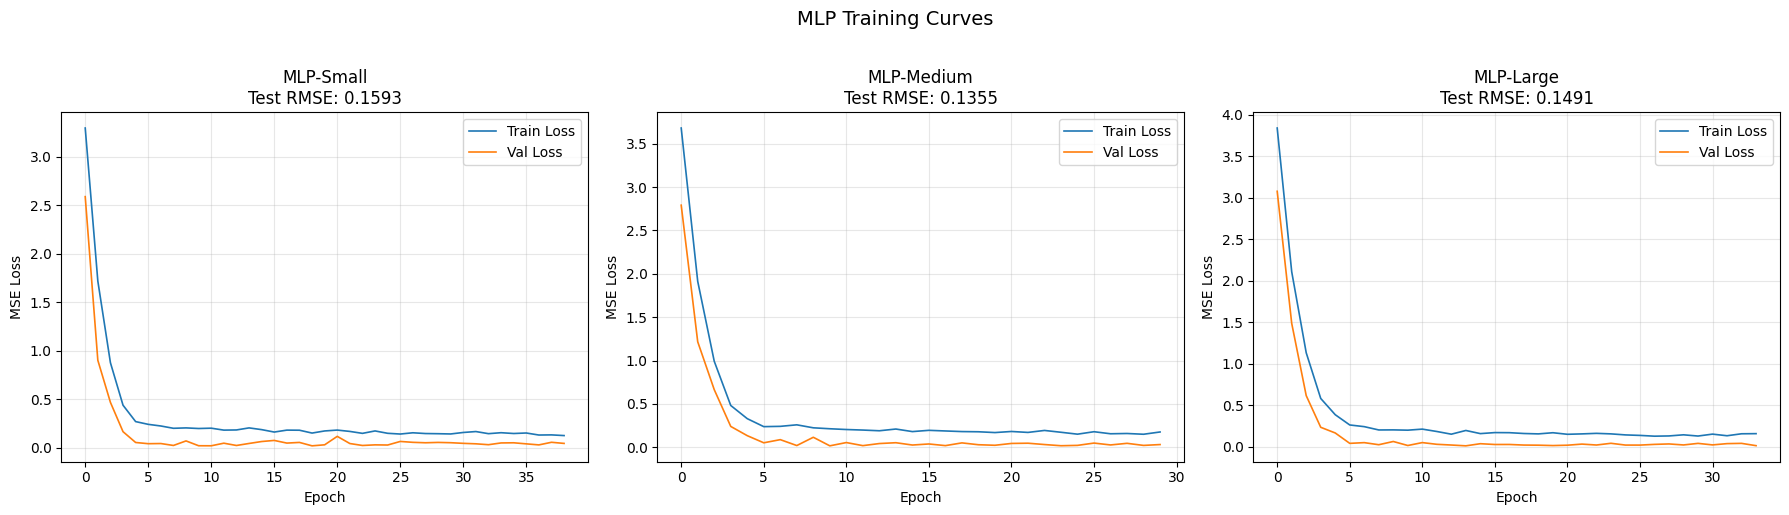

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, mlp_results.items()):
    ax.plot(res['train_losses'], label='Train Loss', linewidth=1.2)
    ax.plot(res['val_losses'], label='Val Loss', linewidth=1.2)
    ax.set_title(f'{name}\nTest RMSE: {res["test_metrics"]["RMSE"]:.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MLP Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Evaluate Best MLP and Save Results

In [9]:
# Select best MLP by validation RMSE
best_mlp_name = min(mlp_results, key=lambda k: mlp_results[k]['val_metrics']['RMSE'])
best_mlp = mlp_results[best_mlp_name]

print(f'Best MLP: {best_mlp_name}')
print(f'  Val  metrics: {best_mlp["val_metrics"]}')
print(f'  Test metrics: {best_mlp["test_metrics"]}')

# Save all MLP results
for name, res in mlp_results.items():
    save_results(
        model_name=name,
        horizon=1,
        metrics={'val': res['val_metrics'], 'test': res['test_metrics']},
        predictions={'val': res['val_pred'], 'test': res['test_pred']},
        dates={'val': val_df['Date'].values, 'test': test_df['Date'].values},
        feature_mode='full'
    )

Best MLP: MLP-Large
  Val  metrics: {'RMSE': 0.118558, 'MAE': 0.099552, 'MAPE': 3.6832}
  Test metrics: {'RMSE': 0.149128, 'MAE': 0.115593, 'MAPE': 4.8675}
Results saved to results/mlp-small_h1_full.json
Results saved to results/mlp-medium_h1_full.json
Results saved to results/mlp-large_h1_full.json


## 4. LSTM Model (PyTorch)

We use a sliding window to create sequences of `(seq_len, n_features)` and feed them
into an LSTM network. The final hidden state is passed through a linear layer to produce
a single prediction.

In [10]:
# ---------------------------------------------------------------------------
# Sequence creation for LSTM/GRU
# ---------------------------------------------------------------------------

def create_sequences(X, y, seq_len):
    """
    Create sliding window sequences.
    X: (n_samples, n_features)
    y: (n_samples,)
    Returns X_seq: (n_valid, seq_len, n_features), y_seq: (n_valid,)
    """
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i - seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


def prepare_seq_data(data, feature_cols, seq_len):
    """
    Prepare sequential data for LSTM/GRU.
    Concatenates all splits, scales (fit on train), creates sequences,
    then re-splits based on original split indices.
    """
    train_df = data['train']
    val_df = data['val']
    test_df = data['test']

    X_all = pd.concat([train_df[feature_cols], val_df[feature_cols],
                       test_df[feature_cols]], axis=0).values
    y_all = pd.concat([train_df['target'], val_df['target'],
                       test_df['target']], axis=0).values

    n_train = len(train_df)
    n_val = len(val_df)

    # Scale (fit on train only)
    sc = StandardScaler()
    sc.fit(X_all[:n_train])
    X_all_scaled = sc.transform(X_all)

    # Create sequences
    X_seq, y_seq = create_sequences(X_all_scaled, y_all, seq_len)

    # Split indices after windowing
    train_end = n_train - seq_len
    val_end = n_train + n_val - seq_len

    # Aligned dates
    all_dates = pd.concat([train_df['Date'], val_df['Date'],
                           test_df['Date']], axis=0).values
    dates_seq = all_dates[seq_len:]

    return {
        'X_train': X_seq[:train_end], 'y_train': y_seq[:train_end],
        'X_val': X_seq[train_end:val_end], 'y_val': y_seq[train_end:val_end],
        'X_test': X_seq[val_end:], 'y_test': y_seq[val_end:],
        'val_dates': dates_seq[train_end:val_end],
        'test_dates': dates_seq[val_end:],
    }


print('Sequence utility functions defined.')

Sequence utility functions defined.


In [11]:
class LSTMModel(nn.Module):
    """LSTM network for time series regression."""

    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the final hidden state of the last layer
        out = self.dropout(h_n[-1])  # (batch, hidden_size)
        out = self.fc(out)           # (batch, 1)
        return out.squeeze(-1)


def train_seq_model(model, train_loader, val_loader, epochs=200, patience=20, lr=1e-3):
    """
    Train a sequential model (LSTM or GRU) with Adam, MSELoss, and early stopping.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        # Validation
        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
                n_val += 1
        val_loss /= n_val
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch + 1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}: train_loss={train_losses[-1]:.6f}, '
                  f'val_loss={val_loss:.6f}')

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_seq(model, X_np):
    """Get predictions from a sequential model as a numpy array."""
    model.eval()
    X_t = torch.FloatTensor(X_np).to(device)
    with torch.no_grad():
        preds = model(X_t).cpu().numpy()
    return preds


print('LSTM model class and training functions defined.')

LSTM model class and training functions defined.


### 4.1 Experiment with LSTM Configurations

| Config | Hidden Size | Layers | Seq Len |
|--------|------------|--------|--------|
| LSTM-A | 32 | 1 | 8 |
| LSTM-B | 64 | 1 | 12 |
| LSTM-C | 64 | 2 | 12 |
| LSTM-D | 128 | 2 | 12 |

In [12]:
lstm_configs = {
    'LSTM-A (h=32,L=1,s=8)':  {'hidden_size': 32,  'num_layers': 1, 'seq_len': 8},
    'LSTM-B (h=64,L=1,s=12)': {'hidden_size': 64,  'num_layers': 1, 'seq_len': 12},
    'LSTM-C (h=64,L=2,s=12)': {'hidden_size': 64,  'num_layers': 2, 'seq_len': 12},
    'LSTM-D (h=128,L=2,s=12)':{'hidden_size': 128, 'num_layers': 2, 'seq_len': 12},
}

lstm_results = {}
n_features = len(feature_cols)

for name, cfg in lstm_configs.items():
    print(f'\n{"="*60}')
    print(f'Training {name}')
    print(f'{"="*60}')

    seq_len = cfg['seq_len']
    seq_data = prepare_seq_data(data, feature_cols, seq_len)

    print(f'  Sequence shape: {seq_data["X_train"].shape}')

    # DataLoaders
    tr_ds = TensorDataset(
        torch.FloatTensor(seq_data['X_train']),
        torch.FloatTensor(seq_data['y_train'])
    )
    va_ds = TensorDataset(
        torch.FloatTensor(seq_data['X_val']),
        torch.FloatTensor(seq_data['y_val'])
    )
    tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=32, shuffle=False)

    torch.manual_seed(SEED)
    model = LSTMModel(
        input_size=n_features,
        hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'],
        dropout=0.2
    )
    print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

    model, t_losses, v_losses = train_seq_model(
        model, tr_loader, va_loader,
        epochs=200, patience=20, lr=1e-3
    )

    val_pred = predict_seq(model, seq_data['X_val'])
    test_pred = predict_seq(model, seq_data['X_test'])

    val_metrics = evaluate_model(seq_data['y_val'], val_pred)
    test_metrics = evaluate_model(seq_data['y_test'], test_pred)

    lstm_results[name] = {
        'model': model,
        'train_losses': t_losses,
        'val_losses': v_losses,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'val_pred': val_pred,
        'test_pred': test_pred,
        'seq_data': seq_data,
        'config': cfg,
    }

    print(f'  Epochs trained: {len(t_losses)}')
    print(f'  Val  - RMSE: {val_metrics["RMSE"]:.4f}, MAE: {val_metrics["MAE"]:.4f}, MAPE: {val_metrics["MAPE"]:.2f}%')
    print(f'  Test - RMSE: {test_metrics["RMSE"]:.4f}, MAE: {test_metrics["MAE"]:.4f}, MAPE: {test_metrics["MAPE"]:.2f}%')


Training LSTM-A (h=32,L=1,s=8)
  Sequence shape: (935, 8, 26)
  Parameters: 7,713
  Epoch  50: train_loss=0.034542, val_loss=0.008824
  Early stopping at epoch 71
  Epochs trained: 71
  Val  - RMSE: 0.0809, MAE: 0.0623, MAPE: 2.31%
  Test - RMSE: 0.0999, MAE: 0.0818, MAPE: 3.25%

Training LSTM-B (h=64,L=1,s=12)
  Sequence shape: (931, 12, 26)
  Parameters: 23,617
  Epoch  50: train_loss=0.023951, val_loss=0.005653
  Early stopping at epoch 69
  Epochs trained: 69
  Val  - RMSE: 0.0709, MAE: 0.0535, MAPE: 1.99%
  Test - RMSE: 0.0921, MAE: 0.0733, MAPE: 2.91%

Training LSTM-C (h=64,L=2,s=12)
  Sequence shape: (931, 12, 26)
  Parameters: 56,897
  Early stopping at epoch 47
  Epochs trained: 47
  Val  - RMSE: 0.0809, MAE: 0.0635, MAPE: 2.41%
  Test - RMSE: 0.1003, MAE: 0.0794, MAPE: 3.25%

Training LSTM-D (h=128,L=2,s=12)
  Sequence shape: (931, 12, 26)
  Parameters: 212,097
  Early stopping at epoch 47
  Epochs trained: 47
  Val  - RMSE: 0.0784, MAE: 0.0600, MAPE: 2.27%
  Test - RMSE: 0.

### 4.2 Plot LSTM Training Curves

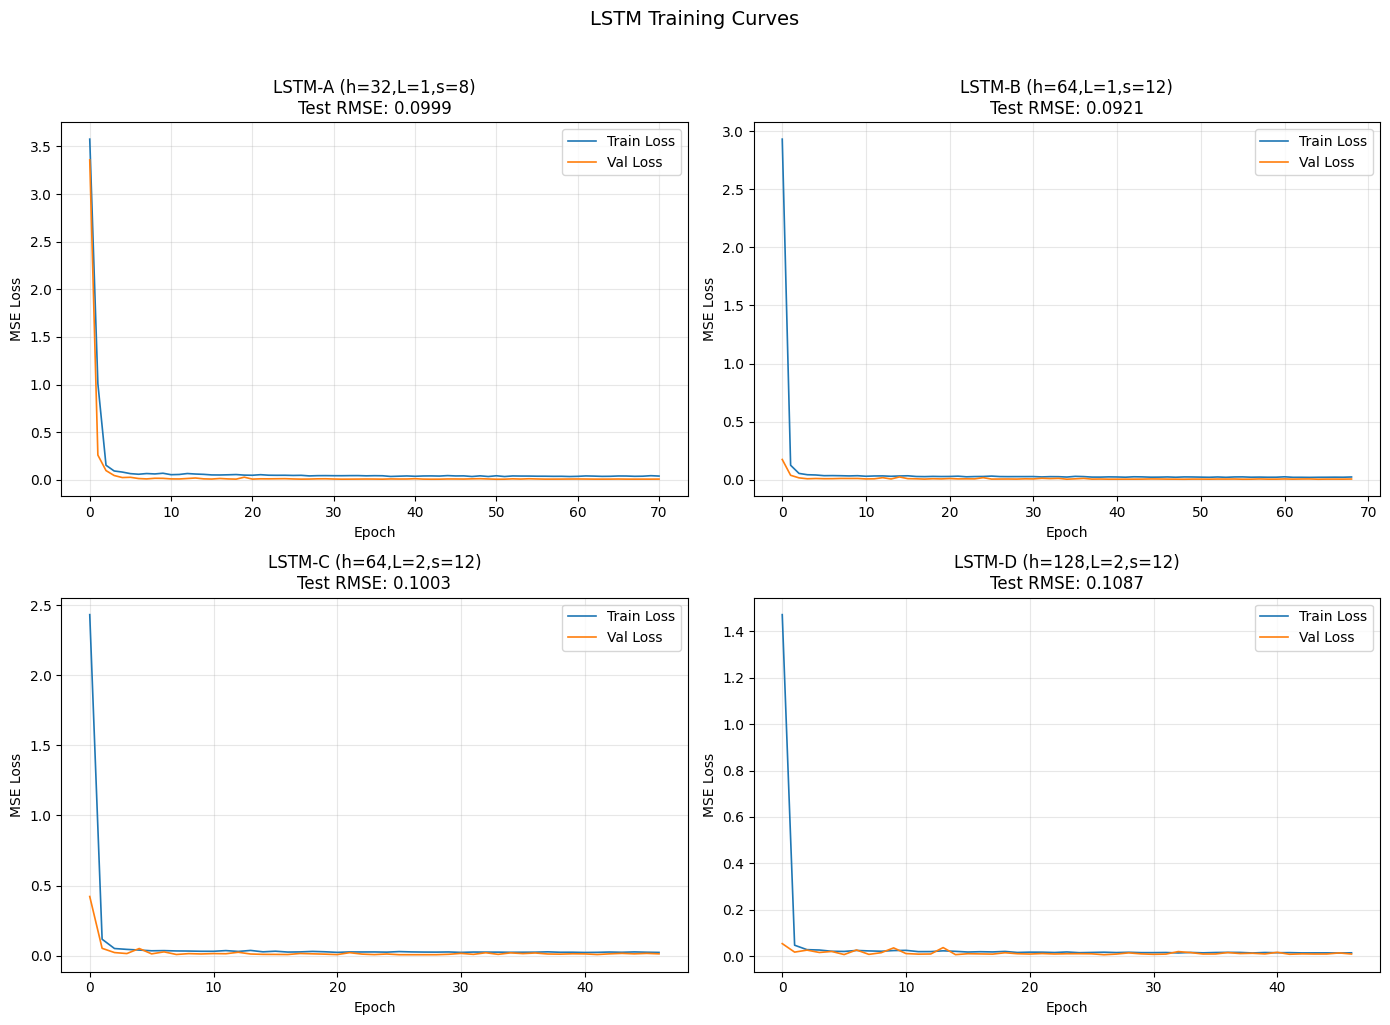

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flatten(), lstm_results.items()):
    ax.plot(res['train_losses'], label='Train Loss', linewidth=1.2)
    ax.plot(res['val_losses'], label='Val Loss', linewidth=1.2)
    ax.set_title(f'{name}\nTest RMSE: {res["test_metrics"]["RMSE"]:.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Evaluate Best LSTM and Save Results

In [14]:
# Select best LSTM by validation RMSE
best_lstm_name = min(lstm_results, key=lambda k: lstm_results[k]['val_metrics']['RMSE'])
best_lstm = lstm_results[best_lstm_name]

print(f'Best LSTM: {best_lstm_name}')
print(f'  Val  metrics: {best_lstm["val_metrics"]}')
print(f'  Test metrics: {best_lstm["test_metrics"]}')

# Save all LSTM results
for name, res in lstm_results.items():
    sd = res['seq_data']
    save_results(
        model_name=name,
        horizon=1,
        metrics={'val': res['val_metrics'], 'test': res['test_metrics']},
        predictions={'val': res['val_pred'], 'test': res['test_pred']},
        dates={'val': sd['val_dates'], 'test': sd['test_dates']},
        feature_mode='full'
    )

Best LSTM: LSTM-B (h=64,L=1,s=12)
  Val  metrics: {'RMSE': 0.070903, 'MAE': 0.0535, 'MAPE': 1.9883}
  Test metrics: {'RMSE': 0.092102, 'MAE': 0.0733, 'MAPE': 2.9109}
Results saved to results/lstm-a_(h=32,l=1,s=8)_h1_full.json
Results saved to results/lstm-b_(h=64,l=1,s=12)_h1_full.json
Results saved to results/lstm-c_(h=64,l=2,s=12)_h1_full.json
Results saved to results/lstm-d_(h=128,l=2,s=12)_h1_full.json


## 5. GRU Model (PyTorch)

Same structure as LSTM but using `nn.GRU`. GRU has fewer parameters than LSTM
(no separate cell state) and can sometimes train faster.

Configuration: hidden=64, layers=2, seq_len=12.

In [15]:
class GRUModel(nn.Module):
    """GRU network for time series regression."""

    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        gru_out, h_n = self.gru(x)
        out = self.dropout(h_n[-1])  # (batch, hidden_size)
        out = self.fc(out)           # (batch, 1)
        return out.squeeze(-1)


print('GRU model class defined.')

GRU model class defined.


In [16]:
# Prepare GRU data with seq_len=12
GRU_SEQ_LEN = 12
gru_seq_data = prepare_seq_data(data, feature_cols, GRU_SEQ_LEN)

gru_tr_ds = TensorDataset(
    torch.FloatTensor(gru_seq_data['X_train']),
    torch.FloatTensor(gru_seq_data['y_train'])
)
gru_va_ds = TensorDataset(
    torch.FloatTensor(gru_seq_data['X_val']),
    torch.FloatTensor(gru_seq_data['y_val'])
)
gru_tr_loader = DataLoader(gru_tr_ds, batch_size=32, shuffle=True)
gru_va_loader = DataLoader(gru_va_ds, batch_size=32, shuffle=False)

print(f'GRU data prepared: train={len(gru_seq_data["X_train"])}, '
      f'val={len(gru_seq_data["X_val"])}, test={len(gru_seq_data["X_test"])}')

torch.manual_seed(SEED)
gru_model = GRUModel(
    input_size=n_features,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
)
print(f'GRU Parameters: {sum(p.numel() for p in gru_model.parameters()):,}')

gru_model, gru_t_losses, gru_v_losses = train_seq_model(
    gru_model, gru_tr_loader, gru_va_loader,
    epochs=200, patience=20, lr=1e-3
)

gru_val_pred = predict_seq(gru_model, gru_seq_data['X_val'])
gru_test_pred = predict_seq(gru_model, gru_seq_data['X_test'])

gru_val_metrics = evaluate_model(gru_seq_data['y_val'], gru_val_pred)
gru_test_metrics = evaluate_model(gru_seq_data['y_test'], gru_test_pred)

print(f'\nGRU (hidden=64, layers=2, seq_len={GRU_SEQ_LEN}):')
print(f'  Val  - RMSE: {gru_val_metrics["RMSE"]:.4f}, MAE: {gru_val_metrics["MAE"]:.4f}, MAPE: {gru_val_metrics["MAPE"]:.2f}%')
print(f'  Test - RMSE: {gru_test_metrics["RMSE"]:.4f}, MAE: {gru_test_metrics["MAE"]:.4f}, MAPE: {gru_test_metrics["MAPE"]:.2f}%')

# Save GRU results
save_results(
    model_name='GRU (h=64,L=2,s=12)',
    horizon=1,
    metrics={'val': gru_val_metrics, 'test': gru_test_metrics},
    predictions={'val': gru_val_pred, 'test': gru_test_pred},
    dates={'val': gru_seq_data['val_dates'], 'test': gru_seq_data['test_dates']},
    feature_mode='full'
)

GRU data prepared: train=931, val=202, test=203
GRU Parameters: 42,689
  Epoch  50: train_loss=0.024839, val_loss=0.011257
  Early stopping at epoch 55

GRU (hidden=64, layers=2, seq_len=12):
  Val  - RMSE: 0.0752, MAE: 0.0568, MAPE: 2.09%
  Test - RMSE: 0.0933, MAE: 0.0742, MAPE: 2.91%
Results saved to results/gru_(h=64,l=2,s=12)_h1_full.json


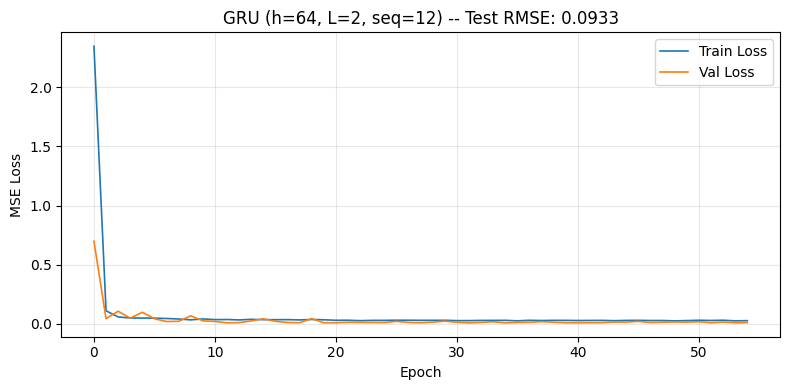

In [17]:
# Plot GRU training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gru_t_losses, label='Train Loss', linewidth=1.2)
ax.plot(gru_v_losses, label='Val Loss', linewidth=1.2)
ax.set_title(f'GRU (h=64, L=2, seq=12) -- Test RMSE: {gru_test_metrics["RMSE"]:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparison: All Neural Network Variants (Horizon=1)

In [18]:
print('=' * 90)
print('Neural Network Model Comparison -- Horizon=1, Test Set')
print('=' * 90)
print(f'{"Model":<35} {"RMSE":>10} {"MAE":>10} {"MAPE (%)":>10}')
print('-' * 65)

all_h1 = {}

# MLP results
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['test_metrics']['RMSE']):
    m = res['test_metrics']
    print(f'{name:<35} {m["RMSE"]:>10.4f} {m["MAE"]:>10.4f} {m["MAPE"]:>10.2f}')
    all_h1[name] = res

# LSTM results
for name, res in sorted(lstm_results.items(), key=lambda x: x[1]['test_metrics']['RMSE']):
    m = res['test_metrics']
    print(f'{name:<35} {m["RMSE"]:>10.4f} {m["MAE"]:>10.4f} {m["MAPE"]:>10.2f}')
    all_h1[name] = res

# GRU
gru_label = 'GRU (h=64,L=2,s=12)'
print(f'{gru_label:<35} {gru_test_metrics["RMSE"]:>10.4f} {gru_test_metrics["MAE"]:>10.4f} {gru_test_metrics["MAPE"]:>10.2f}')

Neural Network Model Comparison -- Horizon=1, Test Set
Model                                     RMSE        MAE   MAPE (%)
-----------------------------------------------------------------
MLP-Medium                              0.1355     0.1065       4.30
MLP-Large                               0.1491     0.1156       4.87
MLP-Small                               0.1593     0.1317       5.23
LSTM-B (h=64,L=1,s=12)                  0.0921     0.0733       2.91
LSTM-A (h=32,L=1,s=8)                   0.0999     0.0818       3.25
LSTM-C (h=64,L=2,s=12)                  0.1003     0.0794       3.25
LSTM-D (h=128,L=2,s=12)                 0.1087     0.0893       3.60
GRU (h=64,L=2,s=12)                     0.0933     0.0742       2.91


## 7. 4-Week Horizon Forecasting

We retrain the best MLP and the best LSTM configuration with `horizon=4`.

In [19]:
# Prepare horizon=4 data
data_h4 = prepare_data(horizon=4, feature_mode='full')

train_df_h4 = data_h4['train']
val_df_h4 = data_h4['val']
test_df_h4 = data_h4['test']
feature_cols_h4 = data_h4['feature_cols']

X_train_h4 = train_df_h4[feature_cols_h4].values
y_train_h4 = train_df_h4['target'].values
X_val_h4 = val_df_h4[feature_cols_h4].values
y_val_h4 = val_df_h4['target'].values
X_test_h4 = test_df_h4[feature_cols_h4].values
y_test_h4 = test_df_h4['target'].values

scaler_h4 = StandardScaler()
X_train_h4_s = scaler_h4.fit_transform(X_train_h4)
X_val_h4_s = scaler_h4.transform(X_val_h4)
X_test_h4_s = scaler_h4.transform(X_test_h4)

print(f'Horizon=4 data: Train={len(train_df_h4)}, Val={len(val_df_h4)}, Test={len(test_df_h4)}')

Horizon=4 data: Train=941, Val=202, Test=202


In [20]:
# ---------------------------------------------------------------------------
# Retrain best MLP on horizon=4
# ---------------------------------------------------------------------------
print(f'Retraining best MLP ({best_mlp_name}) on horizon=4...\n')

tr_ds_h4 = TensorDataset(torch.FloatTensor(X_train_h4_s), torch.FloatTensor(y_train_h4))
va_ds_h4 = TensorDataset(torch.FloatTensor(X_val_h4_s), torch.FloatTensor(y_val_h4))
tr_loader_h4 = DataLoader(tr_ds_h4, batch_size=32, shuffle=True)
va_loader_h4 = DataLoader(va_ds_h4, batch_size=32, shuffle=False)

torch.manual_seed(SEED)
best_mlp_hidden = mlp_configs[best_mlp_name]
mlp_h4_model = MLP(X_train_h4_s.shape[1], best_mlp_hidden, dropout=0.2)
mlp_h4_model, mlp_h4_tl, mlp_h4_vl = train_mlp(
    mlp_h4_model, tr_loader_h4, va_loader_h4,
    epochs=200, patience=20, lr=1e-3
)

mlp_h4_val_pred = predict_mlp(mlp_h4_model, X_val_h4_s)
mlp_h4_test_pred = predict_mlp(mlp_h4_model, X_test_h4_s)

mlp_h4_val_metrics = evaluate_model(y_val_h4, mlp_h4_val_pred)
mlp_h4_test_metrics = evaluate_model(y_test_h4, mlp_h4_test_pred)

print(f'\n{best_mlp_name} (Horizon=4):')
print(f'  Val  - RMSE: {mlp_h4_val_metrics["RMSE"]:.4f}, MAE: {mlp_h4_val_metrics["MAE"]:.4f}, MAPE: {mlp_h4_val_metrics["MAPE"]:.2f}%')
print(f'  Test - RMSE: {mlp_h4_test_metrics["RMSE"]:.4f}, MAE: {mlp_h4_test_metrics["MAE"]:.4f}, MAPE: {mlp_h4_test_metrics["MAPE"]:.2f}%')

save_results(
    model_name=best_mlp_name,
    horizon=4,
    metrics={'val': mlp_h4_val_metrics, 'test': mlp_h4_test_metrics},
    predictions={'val': mlp_h4_val_pred, 'test': mlp_h4_test_pred},
    dates={'val': val_df_h4['Date'].values, 'test': test_df_h4['Date'].values},
    feature_mode='full'
)

Retraining best MLP (MLP-Large) on horizon=4...

  Early stopping at epoch 41

MLP-Large (Horizon=4):
  Val  - RMSE: 0.1755, MAE: 0.1427, MAPE: 4.98%
  Test - RMSE: 0.1471, MAE: 0.1117, MAPE: 4.45%
Results saved to results/mlp-large_h4_full.json


In [21]:
# ---------------------------------------------------------------------------
# Retrain best LSTM on horizon=4
# ---------------------------------------------------------------------------
best_lstm_cfg = best_lstm['config']
best_lstm_seq_len = best_lstm_cfg['seq_len']
print(f'Retraining best LSTM ({best_lstm_name}) on horizon=4...\n')

seq_data_h4 = prepare_seq_data(data_h4, feature_cols_h4, best_lstm_seq_len)

lstm_tr_ds_h4 = TensorDataset(
    torch.FloatTensor(seq_data_h4['X_train']),
    torch.FloatTensor(seq_data_h4['y_train'])
)
lstm_va_ds_h4 = TensorDataset(
    torch.FloatTensor(seq_data_h4['X_val']),
    torch.FloatTensor(seq_data_h4['y_val'])
)
lstm_tr_loader_h4 = DataLoader(lstm_tr_ds_h4, batch_size=32, shuffle=True)
lstm_va_loader_h4 = DataLoader(lstm_va_ds_h4, batch_size=32, shuffle=False)

torch.manual_seed(SEED)
lstm_h4_model = LSTMModel(
    input_size=len(feature_cols_h4),
    hidden_size=best_lstm_cfg['hidden_size'],
    num_layers=best_lstm_cfg['num_layers'],
    dropout=0.2
)
lstm_h4_model, lstm_h4_tl, lstm_h4_vl = train_seq_model(
    lstm_h4_model, lstm_tr_loader_h4, lstm_va_loader_h4,
    epochs=200, patience=20, lr=1e-3
)

lstm_h4_val_pred = predict_seq(lstm_h4_model, seq_data_h4['X_val'])
lstm_h4_test_pred = predict_seq(lstm_h4_model, seq_data_h4['X_test'])

lstm_h4_val_metrics = evaluate_model(seq_data_h4['y_val'], lstm_h4_val_pred)
lstm_h4_test_metrics = evaluate_model(seq_data_h4['y_test'], lstm_h4_test_pred)

print(f'\n{best_lstm_name} (Horizon=4):')
print(f'  Val  - RMSE: {lstm_h4_val_metrics["RMSE"]:.4f}, MAE: {lstm_h4_val_metrics["MAE"]:.4f}, MAPE: {lstm_h4_val_metrics["MAPE"]:.2f}%')
print(f'  Test - RMSE: {lstm_h4_test_metrics["RMSE"]:.4f}, MAE: {lstm_h4_test_metrics["MAE"]:.4f}, MAPE: {lstm_h4_test_metrics["MAPE"]:.2f}%')

save_results(
    model_name=best_lstm_name,
    horizon=4,
    metrics={'val': lstm_h4_val_metrics, 'test': lstm_h4_test_metrics},
    predictions={'val': lstm_h4_val_pred, 'test': lstm_h4_test_pred},
    dates={'val': seq_data_h4['val_dates'], 'test': seq_data_h4['test_dates']},
    feature_mode='full'
)

Retraining best LSTM (LSTM-B (h=64,L=1,s=12)) on horizon=4...

  Early stopping at epoch 31

LSTM-B (h=64,L=1,s=12) (Horizon=4):
  Val  - RMSE: 0.1671, MAE: 0.1296, MAPE: 5.06%
  Test - RMSE: 0.2252, MAE: 0.1755, MAPE: 7.21%
Results saved to results/lstm-b_(h=64,l=1,s=12)_h4_full.json


## 8. Prediction Plots

Overlay the best MLP, best LSTM, and GRU predictions versus actual on the test set.

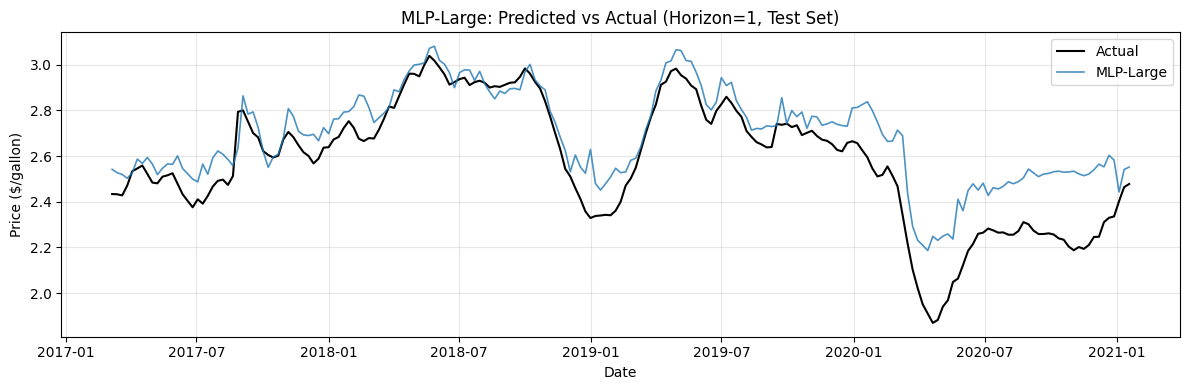

In [22]:
# --- Horizon=1: Best MLP ---
fig = plot_predictions_vs_actual(
    test_df['Date'].values, y_test, best_mlp['test_pred'],
    best_mlp_name,
    title=f'{best_mlp_name}: Predicted vs Actual (Horizon=1, Test Set)'
)
plt.show()

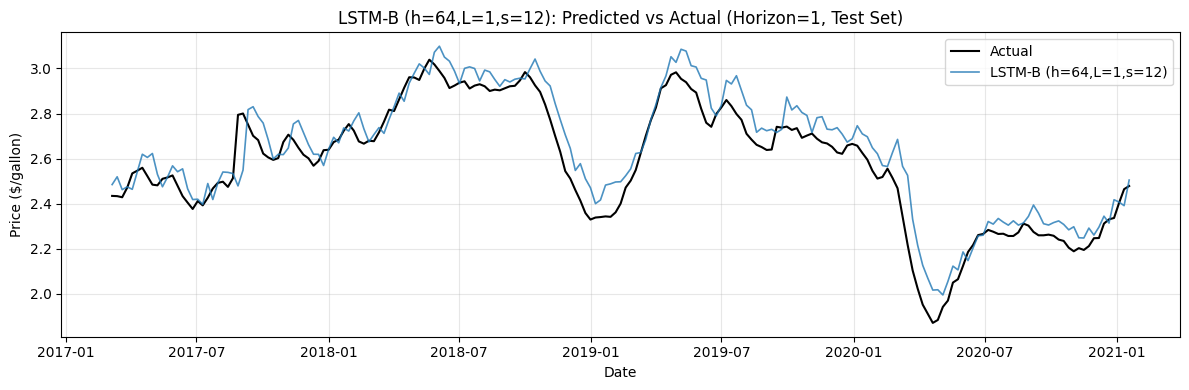

In [23]:
# --- Horizon=1: Best LSTM ---
best_lstm_sd = best_lstm['seq_data']
fig = plot_predictions_vs_actual(
    best_lstm_sd['test_dates'], best_lstm_sd['y_test'], best_lstm['test_pred'],
    best_lstm_name,
    title=f'{best_lstm_name}: Predicted vs Actual (Horizon=1, Test Set)'
)
plt.show()

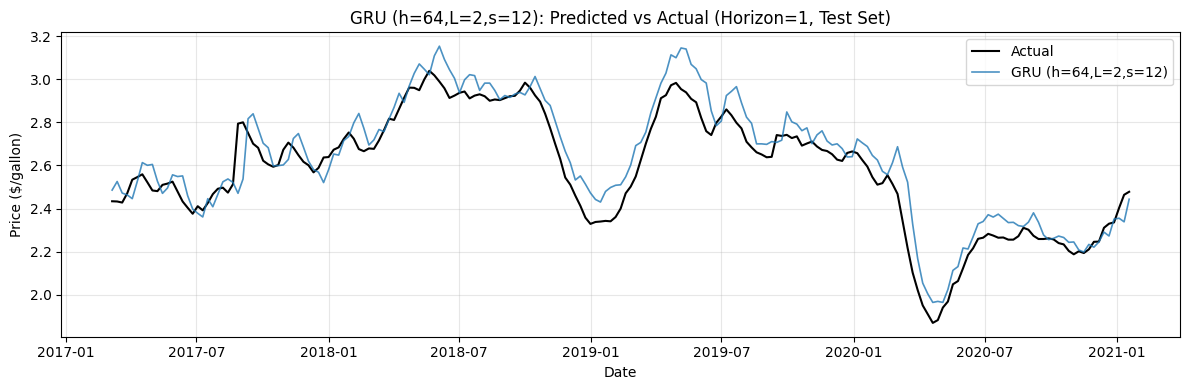

In [24]:
# --- Horizon=1: GRU ---
fig = plot_predictions_vs_actual(
    gru_seq_data['test_dates'], gru_seq_data['y_test'], gru_test_pred,
    'GRU (h=64,L=2,s=12)',
    title='GRU (h=64,L=2,s=12): Predicted vs Actual (Horizon=1, Test Set)'
)
plt.show()

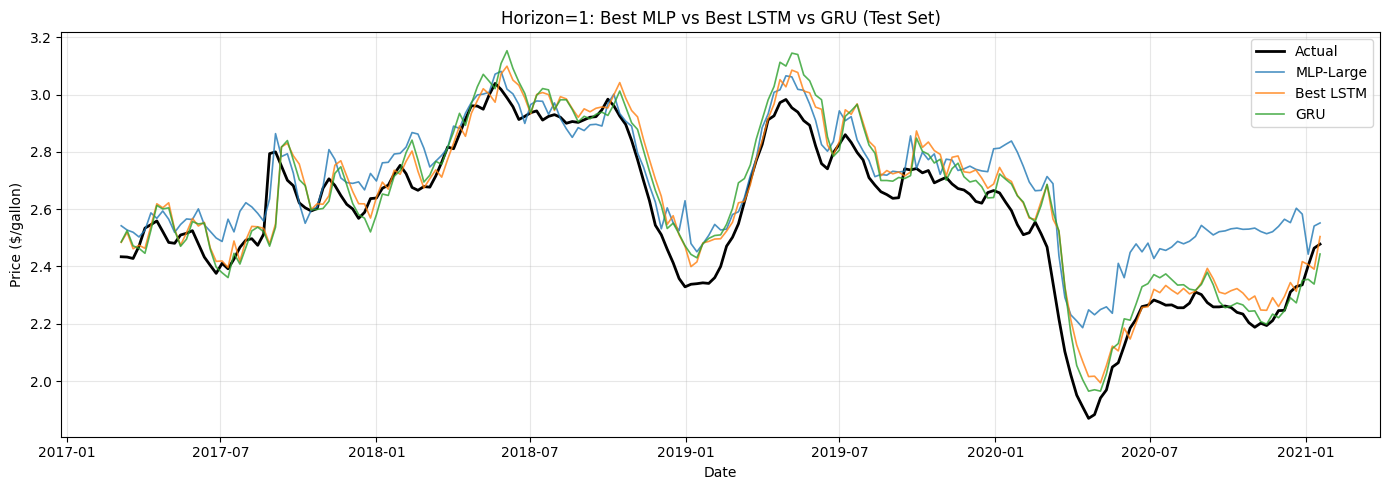

In [25]:
# --- Horizon=1: Overlay best MLP, best LSTM, GRU on same plot ---
# Use the LSTM/GRU test dates (slightly shorter due to seq_len windowing)
# so we align all on the same date range.

# Find overlapping dates
lstm_test_dates = best_lstm_sd['test_dates']
gru_test_dates = gru_seq_data['test_dates']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['Date'].values, y_test, label='Actual', color='black', linewidth=2)
ax.plot(test_df['Date'].values, best_mlp['test_pred'],
        label=f'{best_mlp_name}', color='tab:blue', linewidth=1.2, alpha=0.8)
ax.plot(lstm_test_dates, best_lstm['test_pred'],
        label=f'Best LSTM', color='tab:orange', linewidth=1.2, alpha=0.8)
ax.plot(gru_test_dates, gru_test_pred,
        label='GRU', color='tab:green', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.set_title('Horizon=1: Best MLP vs Best LSTM vs GRU (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

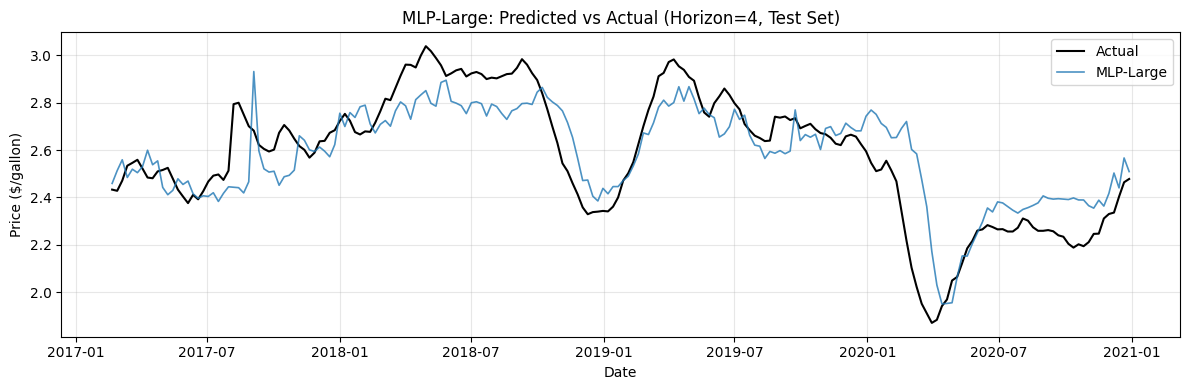

In [26]:
# --- Horizon=4: Best MLP ---
fig = plot_predictions_vs_actual(
    test_df_h4['Date'].values, y_test_h4, mlp_h4_test_pred,
    best_mlp_name,
    title=f'{best_mlp_name}: Predicted vs Actual (Horizon=4, Test Set)'
)
plt.show()

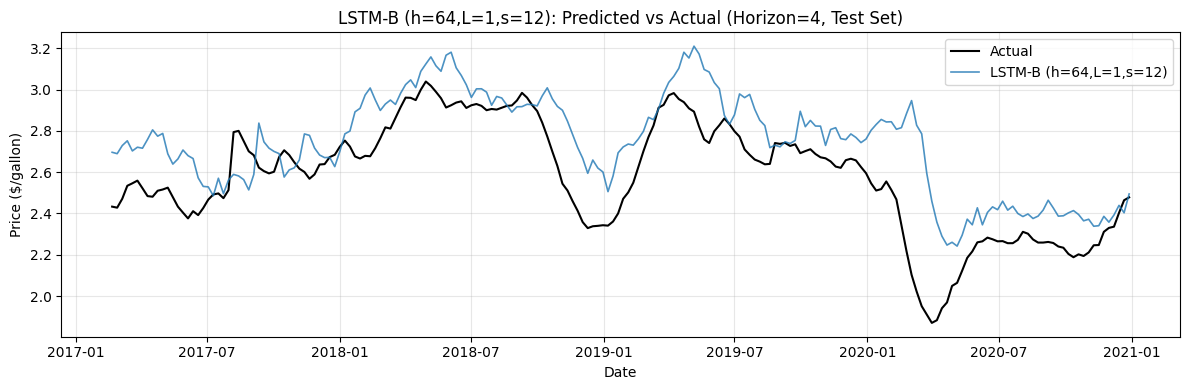

In [27]:
# --- Horizon=4: Best LSTM ---
fig = plot_predictions_vs_actual(
    seq_data_h4['test_dates'], seq_data_h4['y_test'], lstm_h4_test_pred,
    best_lstm_name,
    title=f'{best_lstm_name}: Predicted vs Actual (Horizon=4, Test Set)'
)
plt.show()

## 9. Summary

Full comparison table and bar chart of all neural network model variants.

In [28]:
summary_rows = []

# MLP results (horizon=1)
for name, res in mlp_results.items():
    summary_rows.append({
        'Model': name, 'Type': 'MLP', 'Horizon': 1,
        'Val RMSE': res['val_metrics']['RMSE'],
        'Val MAE': res['val_metrics']['MAE'],
        'Val MAPE (%)': res['val_metrics']['MAPE'],
        'Test RMSE': res['test_metrics']['RMSE'],
        'Test MAE': res['test_metrics']['MAE'],
        'Test MAPE (%)': res['test_metrics']['MAPE'],
    })

# LSTM results (horizon=1)
for name, res in lstm_results.items():
    summary_rows.append({
        'Model': name, 'Type': 'LSTM', 'Horizon': 1,
        'Val RMSE': res['val_metrics']['RMSE'],
        'Val MAE': res['val_metrics']['MAE'],
        'Val MAPE (%)': res['val_metrics']['MAPE'],
        'Test RMSE': res['test_metrics']['RMSE'],
        'Test MAE': res['test_metrics']['MAE'],
        'Test MAPE (%)': res['test_metrics']['MAPE'],
    })

# GRU (horizon=1)
summary_rows.append({
    'Model': 'GRU (h=64,L=2,s=12)', 'Type': 'GRU', 'Horizon': 1,
    'Val RMSE': gru_val_metrics['RMSE'],
    'Val MAE': gru_val_metrics['MAE'],
    'Val MAPE (%)': gru_val_metrics['MAPE'],
    'Test RMSE': gru_test_metrics['RMSE'],
    'Test MAE': gru_test_metrics['MAE'],
    'Test MAPE (%)': gru_test_metrics['MAPE'],
})

# Best MLP horizon=4
summary_rows.append({
    'Model': best_mlp_name, 'Type': 'MLP', 'Horizon': 4,
    'Val RMSE': mlp_h4_val_metrics['RMSE'],
    'Val MAE': mlp_h4_val_metrics['MAE'],
    'Val MAPE (%)': mlp_h4_val_metrics['MAPE'],
    'Test RMSE': mlp_h4_test_metrics['RMSE'],
    'Test MAE': mlp_h4_test_metrics['MAE'],
    'Test MAPE (%)': mlp_h4_test_metrics['MAPE'],
})

# Best LSTM horizon=4
summary_rows.append({
    'Model': best_lstm_name, 'Type': 'LSTM', 'Horizon': 4,
    'Val RMSE': lstm_h4_val_metrics['RMSE'],
    'Val MAE': lstm_h4_val_metrics['MAE'],
    'Val MAPE (%)': lstm_h4_val_metrics['MAPE'],
    'Test RMSE': lstm_h4_test_metrics['RMSE'],
    'Test MAE': lstm_h4_test_metrics['MAE'],
    'Test MAPE (%)': lstm_h4_test_metrics['MAPE'],
})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['Horizon', 'Test RMSE']).reset_index(drop=True)

print('\nNeural Network Model Comparison')
print('=' * 110)
display(summary_df)


Neural Network Model Comparison


,Model,Type,Horizon,Val RMSE,Val MAE,Val MAPE (%),Test RMSE,Test MAE,Test MAPE (%)
0,"LSTM-B (h=64,L=1,s=12)",LSTM,1,0.070903,0.053500,1.9883,0.092102,0.073300,2.9109
1,"GRU (h=64,L=2,s=12)",GRU,1,0.075154,0.056827,2.0864,0.093324,0.074161,2.9080
2,"LSTM-A (h=32,L=1,s=8)",LSTM,1,0.080880,0.062290,2.3107,0.099937,0.081776,3.2521
3,"LSTM-C (h=64,L=2,s=12)",LSTM,1,0.080926,0.063526,2.4052,0.100290,0.079418,3.2547
4,"LSTM-D (h=128,L=2,s=12)",LSTM,1,0.078411,0.060018,2.2726,0.108721,0.089336,3.6036
5,MLP-Medium,MLP,1,0.129102,0.107316,3.6556,0.135500,0.106472,4.2999
6,MLP-Large,MLP,1,0.118558,0.099552,3.6832,0.149128,0.115593,4.8675
7,MLP-Small,MLP,1,0.134272,0.111688,4.0043,0.159265,0.131686,5.2307
8,MLP-Large,MLP,4,0.175477,0.142738,4.9832,0.147071,0.111719,4.4500
9,"LSTM-B (h=64,L=1,s=12)",LSTM,4,0.167145,0.129566,5.0634,0.225166,0.175544,7.2053


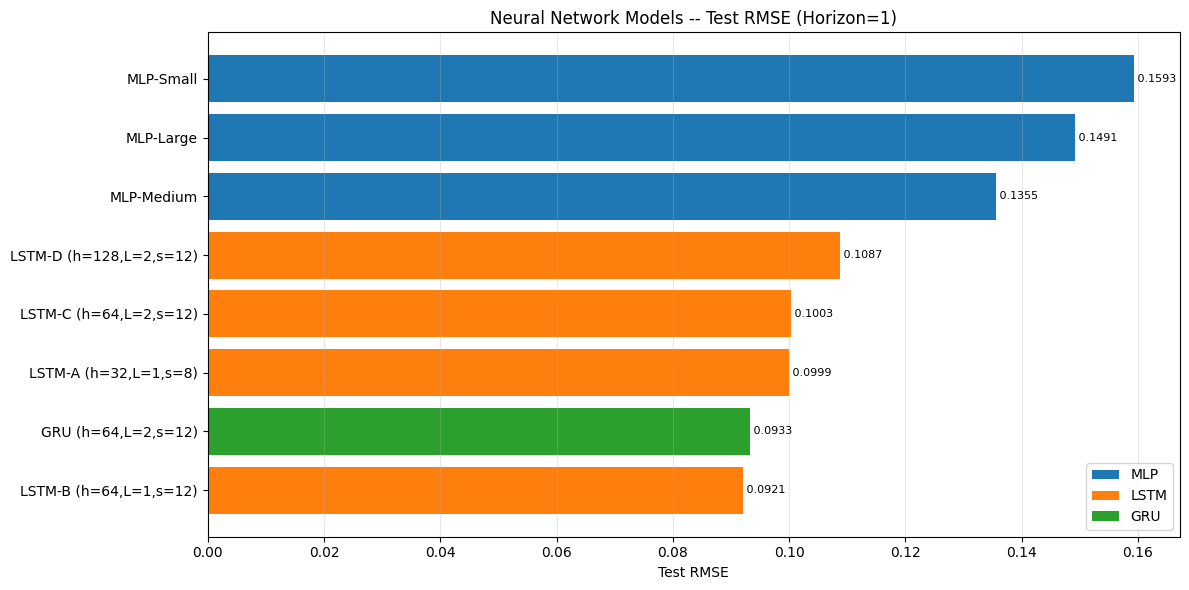

In [29]:
# Bar chart: Test RMSE for Horizon=1 models
h1_df = summary_df[summary_df['Horizon'] == 1].sort_values('Test RMSE')

fig, ax = plt.subplots(figsize=(12, 6))
color_map = {'MLP': 'tab:blue', 'LSTM': 'tab:orange', 'GRU': 'tab:green'}
colors = [color_map.get(t, 'tab:gray') for t in h1_df['Type']]
bars = ax.barh(h1_df['Model'], h1_df['Test RMSE'], color=colors)
ax.set_xlabel('Test RMSE')
ax.set_title('Neural Network Models -- Test RMSE (Horizon=1)')
ax.grid(True, alpha=0.3, axis='x')

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height() / 2,
            f' {width:.4f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', label='MLP'),
                   Patch(facecolor='tab:orange', label='LSTM'),
                   Patch(facecolor='tab:green', label='GRU')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

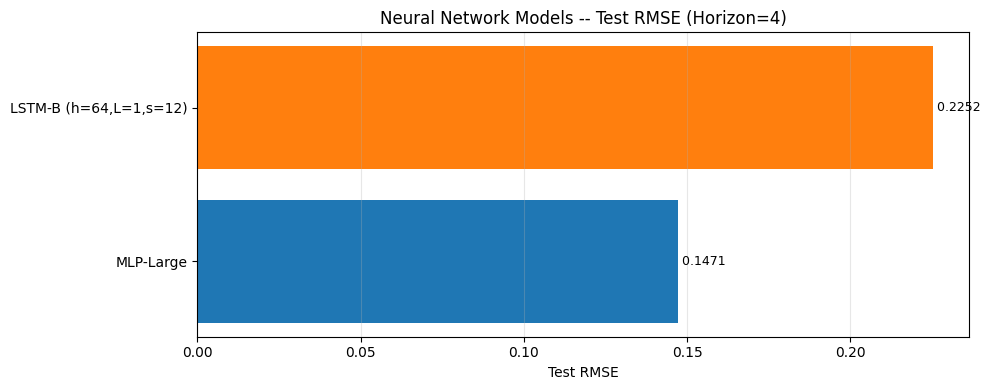

In [30]:
# Bar chart: Test RMSE for Horizon=4 models
h4_df = summary_df[summary_df['Horizon'] == 4].sort_values('Test RMSE')

if len(h4_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    color_map = {'MLP': 'tab:blue', 'LSTM': 'tab:orange', 'GRU': 'tab:green'}
    colors = [color_map.get(t, 'tab:gray') for t in h4_df['Type']]
    bars = ax.barh(h4_df['Model'], h4_df['Test RMSE'], color=colors)
    ax.set_xlabel('Test RMSE')
    ax.set_title('Neural Network Models -- Test RMSE (Horizon=4)')
    ax.grid(True, alpha=0.3, axis='x')

    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height() / 2,
                f' {width:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

## 10. Download Results

Download all saved JSON result files from the `results/` directory.

In [ ]:
# Zip all result JSONs into one file and download
import zipfile
from google.colab import files as colab_files

result_files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.json')])
print(f'Result files ({len(result_files)}):')
for f in result_files:
    print(f'  {f}')

zip_path = 'nn_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in result_files:
        zf.write(os.path.join(RESULTS_DIR, f), f)

print(f'\nZipped into {zip_path}')
colab_files.download(zip_path)
print('Download started — unzip into your local results/ folder')

---

**Notebook complete.** All neural network model results have been saved to the `results/` directory.